<a href="https://colab.research.google.com/github/dineshck2023-cpu/cv_workshop/blob/main/day01_CNN02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CNN

In [11]:
!pip install tensorflow matplotlib

In [12]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [16]:
# Load CIFAR-10 dataset (train + test)
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values (0-255 -> 0-1)
train_images, test_images = train_images / 255.0, test_images / 255.0

# Print shape: (num_images, height, width, channels)
print(train_images.shape)

(50000, 32, 32, 3)


show sample image

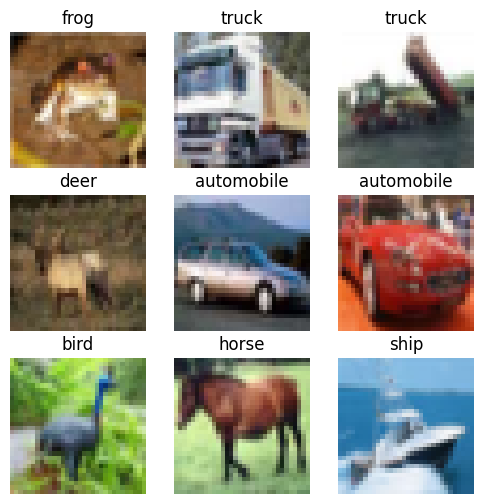

In [18]:
# List of class names (labels) in CIFAR-10 dataset
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Create a figure (canvas) of size 6x6 inches
plt.figure(figsize=(6,6))

# Loop through first 9 images
for i in range(9):
    # Create a 3x3 grid and place each image in correct position
    # i+1 because subplot index starts from 1, not 0
    plt.subplot(3,3,i+1)

    # Display the image
    plt.imshow(train_images[i])
    # Get label index and map to class name
    # train_labels[i][0] gives label number
    plt.title(class_names[train_labels[i][0]])

    # Hide axis numbers
    plt.axis('off')

In [21]:
# Create a Sequential CNN model (layer-by-layer)
model = models.Sequential([

    # First Convolution layer
    # 32 filters, each of size 3x3, detects basic features (edges, patterns)
    # input_shape = (32,32,3) → CIFAR-10 image size (height, width, RGB)
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),

    # Reduce image size (downsampling)
    layers.MaxPooling2D((2,2)),

    # Second Convolution layer
    # 64 filters → learns more complex features
    layers.Conv2D(64, (3,3), activation='relu'),

# Again reduce size
layers.MaxPooling2D((2,2)),

# Flatten 2D feature maps into 1D vector (needed for Dense layers)
layers.Flatten(),

# Fully connected layer (learns patterns)
layers.Dense(64, activation='relu'),

# Output layer
# 10 neurons → one for each class (no activation yet)
layers.Dense(10)
])
# Show model architecture
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Compile the model (configure how it learns)

model.compile(
    optimizer='adam',  # Optimizer updates weights to reduce loss (popular, works well)

    # Loss function measures how wrong the model's predictions are
    # SparseCategoricalCrossentropy is used for multi-class classification (labels as numbers)
    # from_logits=True → output layer has no softmax, so raw values are used
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),

    # Metric to evaluate performance → accuracy (correct predictions %)
    metrics=['accuracy']
)

TRAIN MODEL

In [25]:
# Train the model

# train_images, train_labels → data used for learning
# epochs=3 → model will go through the entire dataset 3 times

# validation_data → used to check performance on unseen data after each epoch
# (helps understand if model is learning well or overfitting)

history = model.fit(train_images, train_labels, epochs=3,
                    validation_data=(test_images, test_labels))

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 42ms/step - accuracy: 0.4803 - loss: 1.4448 - val_accuracy: 0.5998 - val_loss: 1.1571
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6186 - loss: 1.0968 - val_accuracy: 0.6157 - val_loss: 1.1021
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.6626 - loss: 0.9704 - val_accuracy: 0.6622 - val_loss: 0.9696


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

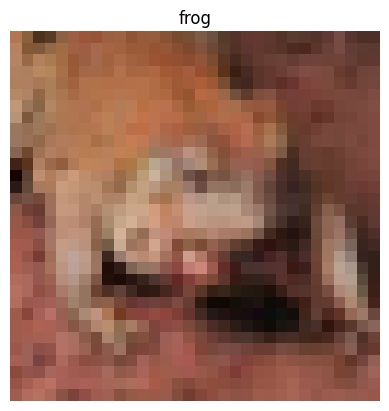

In [26]:
# Import numpy for numerical operations
import numpy as np

# Get predictions for all test images
# Output will be probabilities/logits for each of the 10 classes
predictions = model.predict(test_images)

# Select one image index to display
index = 5

# Show the selected test image
plt.imshow(test_images[index])

# np.argmax(...) -> gets the index of the highest predicted value
# This index corresponds to the predicted class
plt.title(class_names[np.argmax(predictions[index])])

# Hide axis for cleaner display
plt.axis('off')